# Term Deposit Subscription Prediction

**Dataset:** Bank Marketing Dataset — UCI Machine Learning Repository  
**Goal:** Predict whether a customer will subscribe to a term deposit based on marketing campaign data.

**Topics:** Classification · Feature Encoding · Explainable AI (SHAP) · Customer Behaviour Analysis


## · Install Dependencies
Run once.


In [27]:
import subprocess, sys

packages = [
    "pandas", "numpy", "matplotlib", "seaborn",
    "scikit-learn", "shap", "imbalanced-learn", "ucimlrepo"
]

for pkg in packages:
    print(f'Installing {pkg} ...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install',
                           pkg, '-q', '--disable-pip-version-check'])

print('\n All packages installed successfully!')


Installing pandas ...
Installing numpy ...
Installing matplotlib ...
Installing seaborn ...
Installing scikit-learn ...
Installing shap ...
Installing imbalanced-learn ...
Installing ucimlrepo ...

 All packages installed successfully!



## 1 · Imports & Global Theme


In [28]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import shap

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, f1_score,
    roc_curve, auc
)
from imblearn.over_sampling import SMOTE

# ── Global Matplotlib theme ─────────────────────────────────
OBSIDIAN    = "#0d1117"
SURFACE     = "#161b22"
SURFACE2    = "#21262d"
BORDER      = "#30363d"
TEXT        = "#e6edf3"
TEXT_MUTED  = "#8b949e"
BLUE        = "#58a6ff"
GREEN       = "#39d353"
RED         = "#f85149"
VIOLET      = "#d2a8ff"
ORANGE      = "#ffa657"
YELLOW      = "#e3b341"

plt.rcParams.update({
    "figure.facecolor":  OBSIDIAN,
    "axes.facecolor":    SURFACE,
    "axes.edgecolor":    BORDER,
    "axes.labelcolor":   TEXT,
    "axes.titlecolor":   TEXT,
    "axes.grid":         True,
    "grid.color":        SURFACE2,
    "grid.linestyle":    "--",
    "grid.alpha":        0.6,
    "text.color":        TEXT,
    "xtick.color":       TEXT_MUTED,
    "ytick.color":       TEXT_MUTED,
    "legend.facecolor":  SURFACE,
    "legend.edgecolor":  BORDER,
    "legend.labelcolor": TEXT,
    "font.family":       "monospace",
    # "figure.titlecolor": not supported in older matplotlib
})

PALETTE   = [RED, GREEN]        # No / Yes
MODEL_CLR = {
    "Logistic Regression": BLUE,
    "Random Forest":       GREEN,
    "Gradient Boosting":   ORANGE,
}

print(" Imports complete · Theme applied")


 Imports complete · Theme applied


## 2 · Load & Explore Dataset
Auto-fetches from UCI — no manual download needed.


In [29]:
# ── Fetch from UCI ──────────────────────────────────────────
bank  = fetch_ucirepo(id=222)
X_raw = bank.data.features.copy()
y_raw = bank.data.targets.copy()

df = pd.concat([X_raw, y_raw], axis=1)
df.columns = [*X_raw.columns, "y"]

print(f"Shape          : {df.shape}")
print(f"Features       : {list(X_raw.columns)}")
print(f"\nTarget counts :")
print(df["y"].value_counts())
print(f"\nClass balance → yes: {(df['y']=='yes').mean()*100:.1f}%  "
      f"no: {(df['y']=='no').mean()*100:.1f}%")
df.head()


Shape          : (45211, 17)
Features       : ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day_of_week', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome']

Target counts :
y
no     39922
yes     5289
Name: count, dtype: int64

Class balance → yes: 11.7%  no: 88.3%


,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no



### 2a · Numerical Feature Distributions


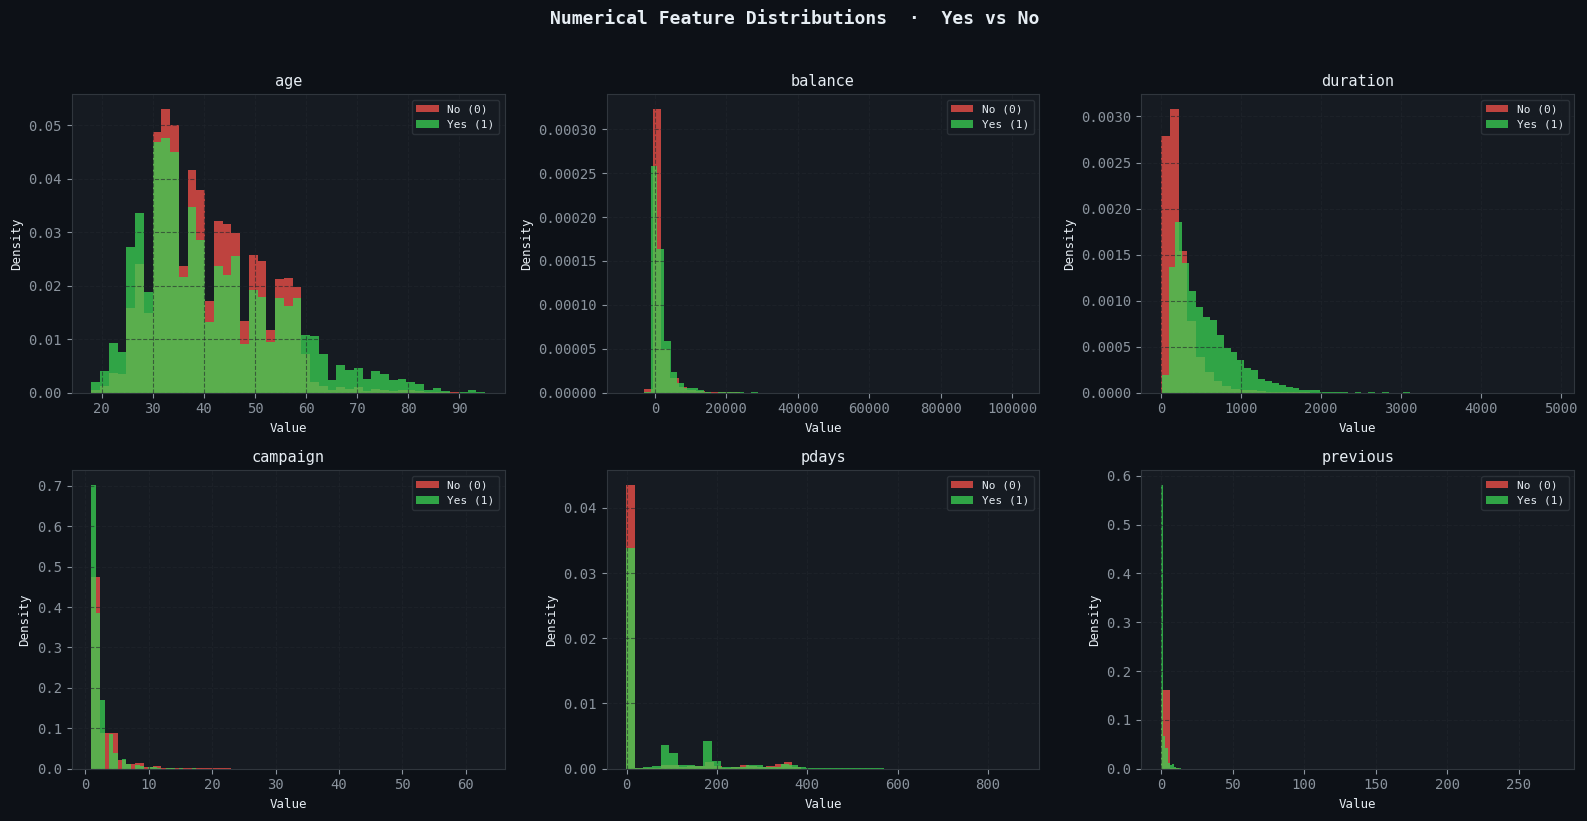

In [30]:
num_cols = ["age", "balance", "duration", "campaign", "pdays", "previous"]
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("Numerical Feature Distributions  ·  Yes vs No",
             fontsize=13, color=TEXT, fontweight="bold", y=1.02)

for ax, col in zip(axes.flat, num_cols):
    yes_data = df.loc[df["y"] == "yes", col]
    no_data  = df.loc[df["y"] == "no",  col]
    ax.hist(no_data,  bins=45, alpha=0.75, color=RED,   label="No (0)",  density=True)
    ax.hist(yes_data, bins=45, alpha=0.75, color=GREEN, label="Yes (1)", density=True)
    ax.set_title(col, fontsize=11, pad=6)
    ax.set_xlabel("Value",   fontsize=9)
    ax.set_ylabel("Density", fontsize=9)
    ax.legend(fontsize=8)
    for spine in ax.spines.values():
        spine.set_edgecolor(BORDER)

plt.tight_layout()
plt.savefig("eda_numerical.png", dpi=140, bbox_inches="tight", facecolor=OBSIDIAN)
plt.show()


---
### 🔍 2b · Subscription Rate by Job & Education


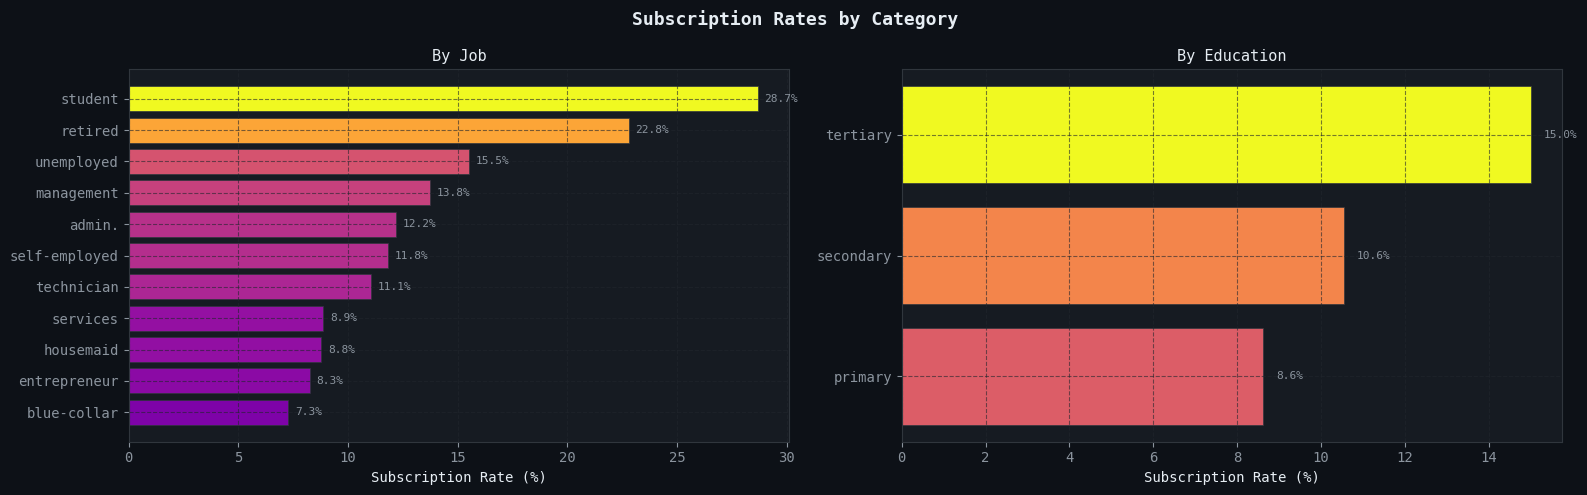

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Subscription Rates by Category", fontsize=13, color=TEXT, fontweight="bold")

for ax, col in zip(axes, ["job", "education"]):
    total  = df.groupby(col).size()
    yes_ct = df[df["y"] == "yes"].groupby(col).size()
    rate   = (yes_ct / total * 100).sort_values(ascending=True)
    colors = [plt.cm.plasma(v / rate.max()) for v in rate.values]
    bars   = ax.barh(rate.index, rate.values, color=colors, edgecolor=BORDER, linewidth=0.5)
    ax.set_xlabel("Subscription Rate (%)", fontsize=10)
    ax.set_title(f"By {col.capitalize()}", fontsize=11)
    for bar, val in zip(bars, rate.values):
        ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
                f"{val:.1f}%", va="center", fontsize=8, color=TEXT_MUTED)
    for spine in ax.spines.values():
        spine.set_edgecolor(BORDER)

plt.tight_layout()
plt.savefig("eda_categories.png", dpi=140, bbox_inches="tight", facecolor=OBSIDIAN)
plt.show()


### 2c · Correlation Heatmap (Numerical Features)


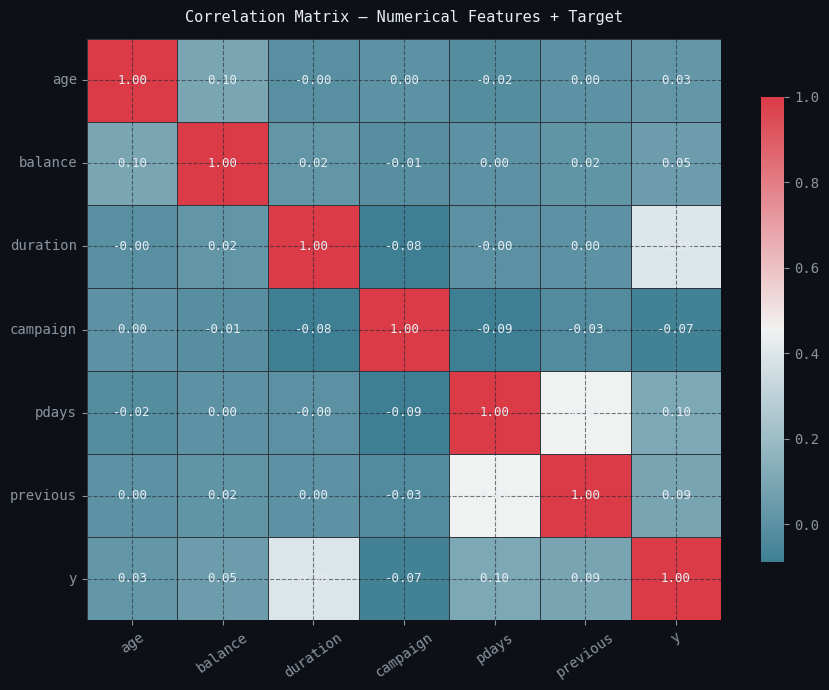

In [32]:
fig, ax = plt.subplots(figsize=(9, 7))
corr = df[num_cols + ["y"]].replace({"yes": 1, "no": 0}).corr()

cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(corr, ax=ax, cmap=cmap, annot=True, fmt=".2f",
            linewidths=0.5, linecolor=BORDER,
            cbar_kws={"shrink": 0.8},
            annot_kws={"size": 9, "color": TEXT})

ax.set_title("Correlation Matrix — Numerical Features + Target",
             fontsize=11, pad=12)
ax.tick_params(axis="x", rotation=35)
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.savefig("eda_correlation.png", dpi=140, bbox_inches="tight", facecolor=OBSIDIAN)
plt.show()


## 3 · Preprocessing & Feature Encoding
- **Target**: Label-encoded  (`no → 0`, `yes → 1`)  
- **Categoricals**: One-Hot encoded (`drop_first=True`)  
- **Imbalance**: Handled with **SMOTE** on training data  
- **Scaling**: `StandardScaler` for Logistic Regression  


In [33]:
df_enc = df.copy()
cat_cols     = df_enc.select_dtypes(include="object").columns.drop("y").tolist()
num_cols_all = df_enc.select_dtypes(include=np.number).columns.tolist()

# Label-encode target
le = LabelEncoder()
df_enc["y"] = le.fit_transform(df_enc["y"])   # no→0, yes→1

# One-hot encode categoricals
df_enc = pd.get_dummies(df_enc, columns=cat_cols, drop_first=True)

print(f"Shape after encoding : {df_enc.shape}")
print(f"Target mapping       : {dict(zip(le.classes_, le.transform(le.classes_)))}")

X = df_enc.drop("y", axis=1)
y = df_enc["y"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# SMOTE — balance training set
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print(f"\n{'':30s} {'Before':>10s}  {'After SMOTE':>12s}")
print(f"{'Train positives (yes)':30s} {y_train.sum():>10d}  {y_train_sm.sum():>12d}")
print(f"{'Train negatives (no)':30s}  {(y_train==0).sum():>10d}  {(y_train_sm==0).sum():>12d}")
print(f"{'Balance':30s} {y_train.mean()*100:>9.1f}%  {y_train_sm.mean()*100:>11.1f}%")

# Scale for Logistic Regression
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_sm)
X_test_sc  = scaler.transform(X_test)
print("\n Preprocessing complete")


Shape after encoding : (45211, 39)
Target mapping       : {'no': np.int64(0), 'yes': np.int64(1)}

                                   Before   After SMOTE
Train positives (yes)                4231         31937
Train negatives (no)                 31937         31937
Balance                             11.7%         50.0%

 Preprocessing complete


## 4 · Train Classification Models
Three models trained and cross-validated:
| Model | Type |
|---|---|
| Logistic Regression | Linear baseline |
| Random Forest | Bagged trees |
| Gradient Boosting | Boosted trees |


In [34]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, C=1.0, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=300, max_depth=12,
                                                   random_state=42, n_jobs=-1),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=200, learning_rate=0.08,
                                                       max_depth=4, random_state=42),
}

trained = {}
cv_results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    X_tr = X_train_sc if "Logistic" in name else X_train_sm
    model.fit(X_tr, y_train_sm)
    trained[name] = model

    scores = cross_val_score(model, X_tr, y_train_sm, cv=cv, scoring="f1")
    cv_results[name] = scores
    print(f"[{name:22s}]  CV F1 = {scores.mean():.4f} ± {scores.std():.4f}")

print("\n  All models trained")


[Logistic Regression   ]  CV F1 = 0.9246 ± 0.0014
[Random Forest         ]  CV F1 = 0.9299 ± 0.0018
[Gradient Boosting     ]  CV F1 = 0.9340 ± 0.0014

  All models trained


### 4a · Cross-Validation F1 Distribution


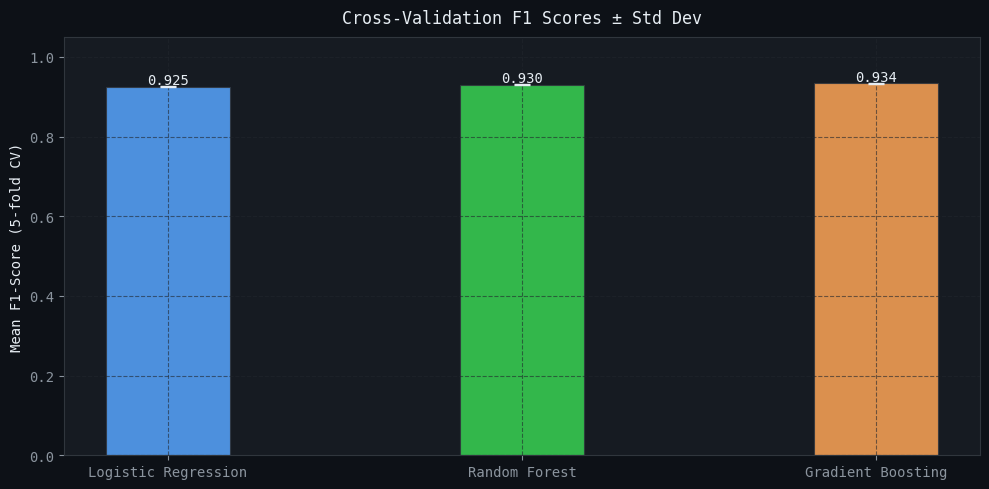

In [35]:
fig, ax = plt.subplots(figsize=(10, 5))
names  = list(cv_results.keys())
colors = [MODEL_CLR[n] for n in names]
x      = np.arange(len(names))
width  = 0.35

for i, (name, scores) in enumerate(cv_results.items()):
    ax.bar(i, scores.mean(), width, color=MODEL_CLR[name],
           alpha=0.85, edgecolor=BORDER, linewidth=0.8, label=name)
    ax.errorbar(i, scores.mean(), yerr=scores.std(),
                fmt="none", color=TEXT, capsize=6, linewidth=1.5)
    ax.text(i, scores.mean() + scores.std() + 0.005,
            f"{scores.mean():.3f}", ha="center", fontsize=10, color=TEXT)

ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=10)
ax.set_ylabel("Mean F1-Score (5-fold CV)")
ax.set_title("Cross-Validation F1 Scores ± Std Dev", fontsize=12, pad=10)
ax.set_ylim(0, 1.05)
for spine in ax.spines.values(): spine.set_edgecolor(BORDER)

plt.tight_layout()
plt.savefig("cv_scores.png", dpi=140, bbox_inches="tight", facecolor=OBSIDIAN)
plt.show()


## 5 · Evaluation — Confusion Matrix · F1 · ROC Curve


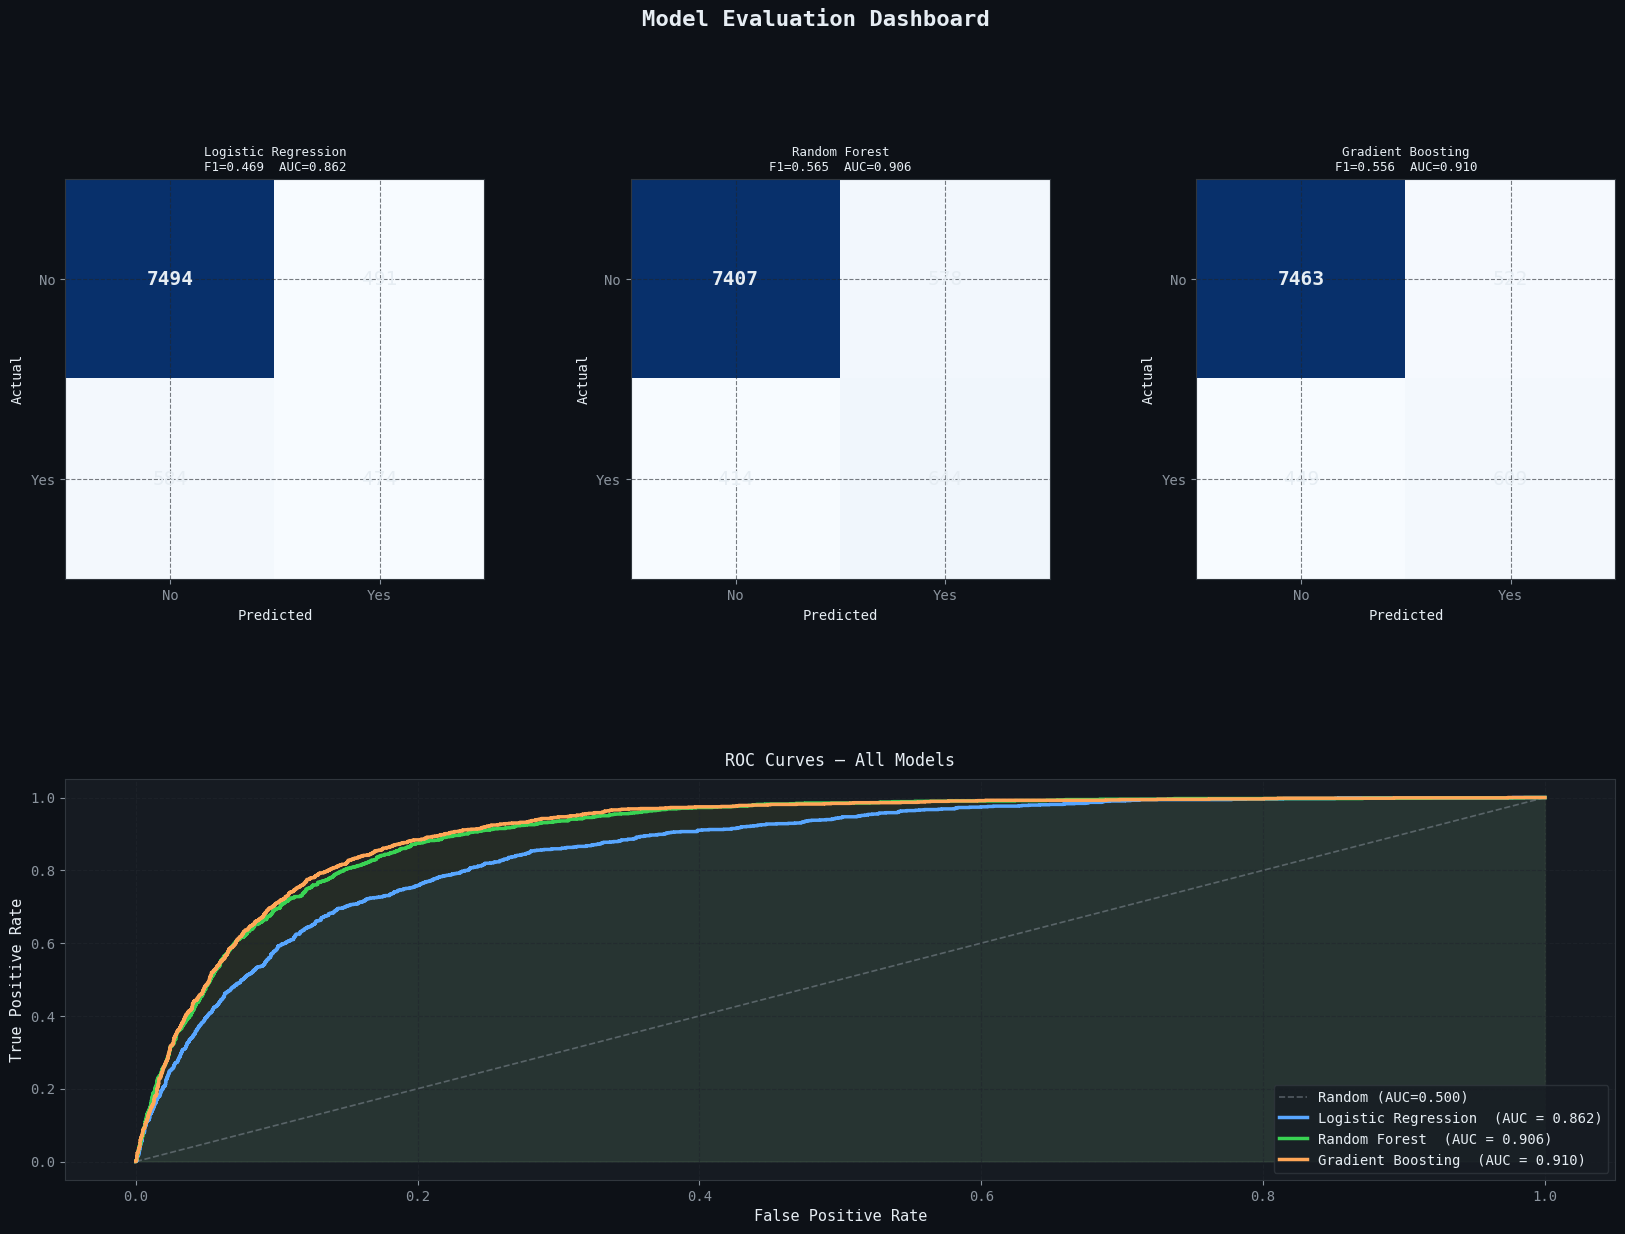


──────────────────────────────────────────────────
  Logistic Regression  —  F1: 0.4686  |  AUC: 0.8615
──────────────────────────────────────────────────
              precision    recall  f1-score   support

      No (0)       0.93      0.94      0.93      7985
     Yes (1)       0.49      0.45      0.47      1058

    accuracy                           0.88      9043
   macro avg       0.71      0.69      0.70      9043
weighted avg       0.88      0.88      0.88      9043


──────────────────────────────────────────────────
  Random Forest  —  F1: 0.5649  |  AUC: 0.9060
──────────────────────────────────────────────────
              precision    recall  f1-score   support

      No (0)       0.95      0.93      0.94      7985
     Yes (1)       0.53      0.61      0.56      1058

    accuracy                           0.89      9043
   macro avg       0.74      0.77      0.75      9043
weighted avg       0.90      0.89      0.89      9043


───────────────────────────────────────

In [36]:
results = {}
n = len(trained)

fig = plt.figure(figsize=(20, 13))
fig.patch.set_facecolor(OBSIDIAN)
fig.suptitle("Model Evaluation Dashboard", fontsize=16,
             color=TEXT, fontweight="bold", y=1.01)
gs = gridspec.GridSpec(2, n, figure=fig, hspace=0.5, wspace=0.35)

ax_roc = fig.add_subplot(gs[1, :])
ax_roc.plot([0, 1], [0, 1], "--", color=TEXT_MUTED, lw=1.2, alpha=0.5, label="Random (AUC=0.500)")
ax_roc.set_facecolor(SURFACE)
ax_roc.set_xlabel("False Positive Rate", fontsize=11)
ax_roc.set_ylabel("True Positive Rate",  fontsize=11)
ax_roc.set_title("ROC Curves — All Models", fontsize=12, pad=10)

for idx, (name, model) in enumerate(trained.items()):
    X_ev    = X_test_sc if "Logistic" in name else X_test
    y_pred  = model.predict(X_ev)
    y_proba = model.predict_proba(X_ev)[:, 1]
    f1      = f1_score(y_test, y_pred)
    cm      = confusion_matrix(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    results[name] = {"f1": f1, "auc": roc_auc, "y_pred": y_pred, "y_proba": y_proba}

    # Confusion matrix
    ax_cm = fig.add_subplot(gs[0, idx])
    ax_cm.set_facecolor(SURFACE)
    im = ax_cm.imshow(cm, interpolation="nearest",
                      cmap=plt.cm.Blues, aspect="auto")
    for r in range(2):
        for c in range(2):
            ax_cm.text(c, r, str(cm[r, c]), ha="center", va="center",
                       fontsize=14, color=TEXT,
                       fontweight="bold" if cm[r, c] == cm.max() else "normal")
    ax_cm.set_xticks([0, 1]); ax_cm.set_xticklabels(["No", "Yes"])
    ax_cm.set_yticks([0, 1]); ax_cm.set_yticklabels(["No", "Yes"])
    ax_cm.set_xlabel("Predicted", fontsize=10); ax_cm.set_ylabel("Actual", fontsize=10)
    ax_cm.set_title(f"{name}\nF1={f1:.3f}  AUC={roc_auc:.3f}", fontsize=9)

    # ROC
    ax_roc.plot(fpr, tpr, lw=2.5, color=MODEL_CLR[name],
                label=f"{name}  (AUC = {roc_auc:.3f})")
    ax_roc.fill_between(fpr, tpr, alpha=0.06, color=MODEL_CLR[name])

ax_roc.legend(loc="lower right", fontsize=10)
for spine in ax_roc.spines.values(): spine.set_edgecolor(BORDER)

plt.savefig("evaluation_dashboard.png", dpi=140, bbox_inches="tight", facecolor=OBSIDIAN)
plt.show()

# Print classification reports
for name, r in results.items():
    print(f"\n{'─'*50}")
    print(f"  {name}  —  F1: {r['f1']:.4f}  |  AUC: {r['auc']:.4f}")
    print('─'*50)
    print(classification_report(y_test, r["y_pred"], target_names=["No (0)", "Yes (1)"]))


## 6 · Feature Importance — Random Forest


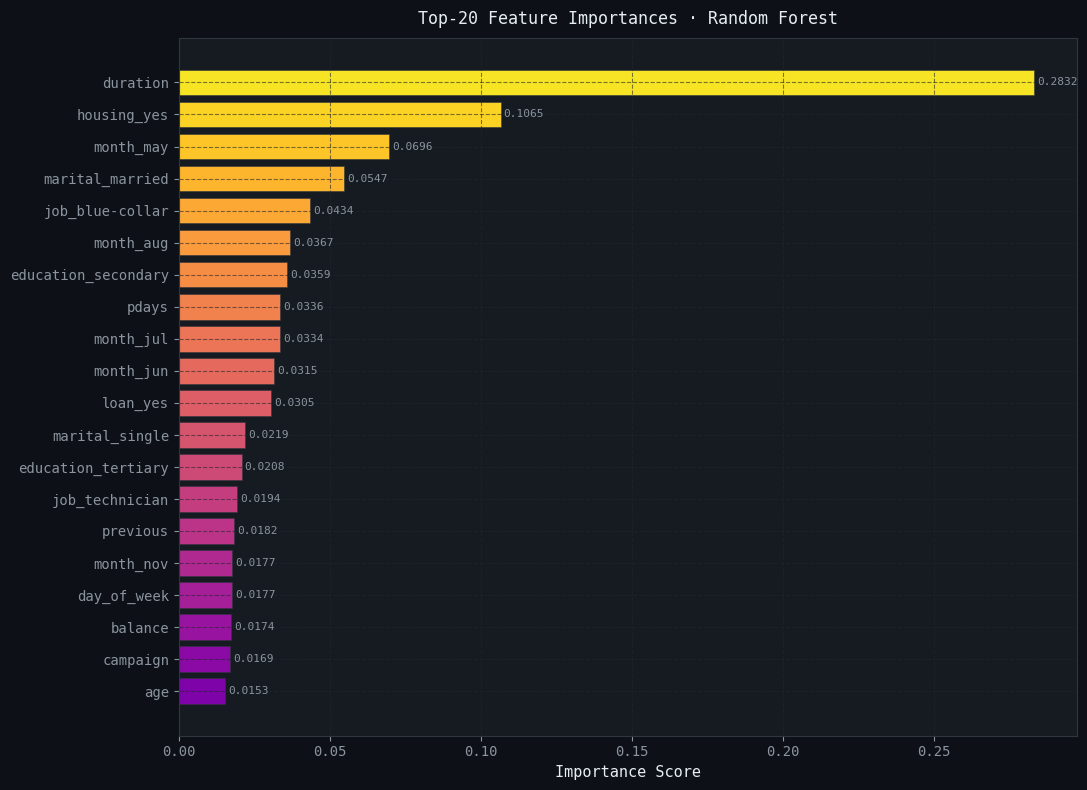

In [37]:
rf      = trained["Random Forest"]
fi      = pd.Series(rf.feature_importances_, index=X.columns)
top20   = fi.nlargest(20).sort_values()

fig, ax = plt.subplots(figsize=(11, 8))
colors  = plt.cm.plasma(np.linspace(0.25, 0.95, len(top20)))
bars    = ax.barh(top20.index, top20.values,
                  color=colors, edgecolor=BORDER, linewidth=0.4)

for bar, val in zip(bars, top20.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=8, color=TEXT_MUTED)

ax.set_xlabel("Importance Score", fontsize=11)
ax.set_title("Top-20 Feature Importances · Random Forest", fontsize=12, pad=10)
for spine in ax.spines.values(): spine.set_edgecolor(BORDER)

plt.tight_layout()
plt.savefig("feature_importance.png", dpi=140, bbox_inches="tight", facecolor=OBSIDIAN)
plt.show()


## 7 · Explainable AI — SHAP Analysis
SHAP (SHapley Additive exPlanations) reveals **why** the model made each prediction.

| Plot Type | Purpose |
|---|---|
| Beeswarm Summary | Global feature impact distribution |
| Bar Summary | Mean absolute SHAP value ranking |
| Waterfall | Individual prediction breakdown |
| Dependence | How one feature affects output |


In [38]:
rf_model  = trained["Random Forest"]
explainer = shap.TreeExplainer(rf_model)

rng        = np.random.RandomState(42)
sample_idx = rng.choice(len(X_test), size=500, replace=False)
X_shap     = X_test.iloc[sample_idx].reset_index(drop=True)
shap_vals  = explainer.shap_values(X_shap)

# ── Handle both old API (list) and new API (3-D array) ──────────
if isinstance(shap_vals, list):
    # Old SHAP: list of [class0_array, class1_array]
    sv_yes = shap_vals[1]                 # shape (n_samples, n_features)
elif shap_vals.ndim == 3:
    # New SHAP: single array shape (n_samples, n_features, n_classes)
    sv_yes = shap_vals[:, :, 1]           # class 1 slice
else:
    # Binary output — single 2-D array already for positive class
    sv_yes = shap_vals

print(f"shap_vals raw shape : {np.array(shap_vals).shape}")
print(f"sv_yes shape        : {sv_yes.shape}  (should be (500, n_features))")
print(f"Base value (yes)    : {explainer.expected_value if np.ndim(explainer.expected_value)==0 else explainer.expected_value[1]:.4f}")
print("  SHAP computation complete")


shap_vals raw shape : (500, 38, 2)
sv_yes shape        : (500, 38)  (should be (500, n_features))
Base value (yes)    : 0.5001
  SHAP computation complete


### 7a · Global Beeswarm Summary Plot
Each dot = one sample. **Colour = feature value** · **Position = SHAP impact**


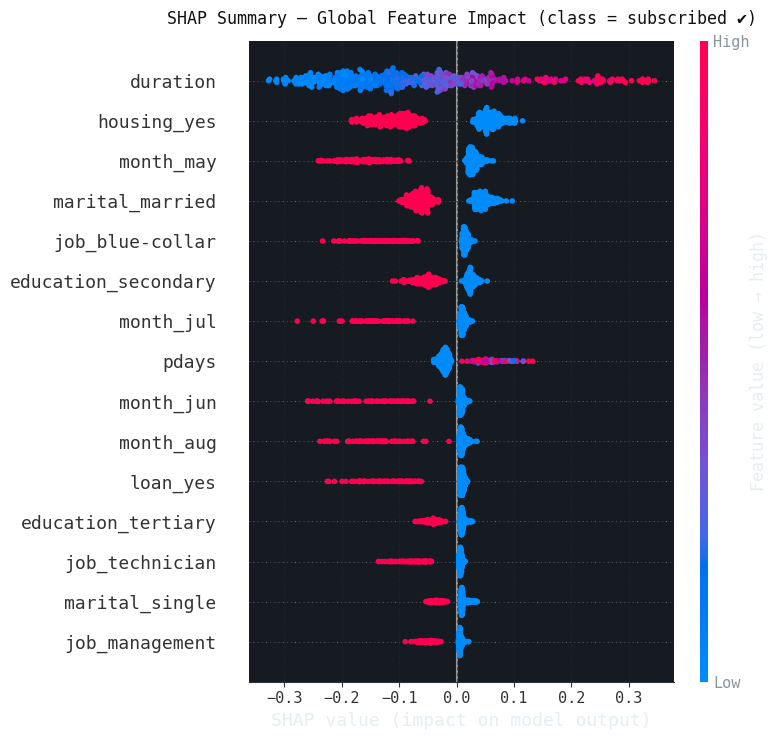

In [39]:
plt.figure(figsize=(11, 8), facecolor="white")
shap.summary_plot(
    sv_yes, X_shap,
    max_display=15,
    show=False,
    plot_type="dot",
    color_bar_label="Feature value (low → high)"
)
plt.title("SHAP Summary — Global Feature Impact (class = subscribed ✔)",
          color="#111", fontsize=12, pad=12)
plt.tight_layout()
plt.savefig("shap_beeswarm.png", dpi=140, bbox_inches="tight", facecolor="white")
plt.show()


### 7b · Mean |SHAP| Feature Importance Bar


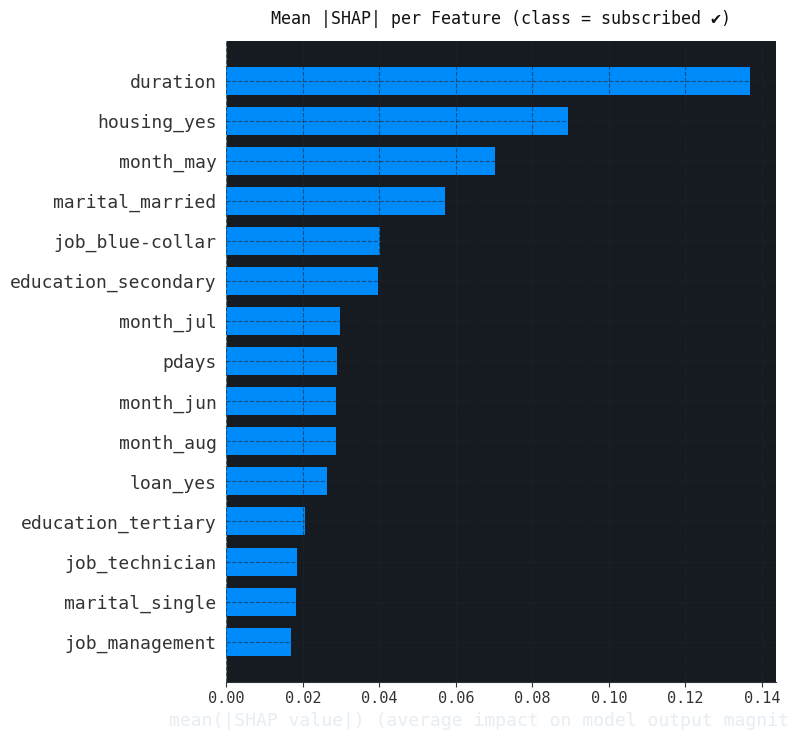

In [40]:
plt.figure(figsize=(10, 6), facecolor="white")
shap.summary_plot(sv_yes, X_shap, max_display=15,
                  show=False, plot_type="bar")
plt.title("Mean |SHAP| per Feature (class = subscribed ✔)",
          color="#111", fontsize=12, pad=12)
plt.tight_layout()
plt.savefig("shap_bar.png", dpi=140, bbox_inches="tight", facecolor="white")
plt.show()


### 7c · Waterfall Plots — 5 Individual Predictions
Showing how each feature **pushed** the prediction up (🔴) or down (🔵).


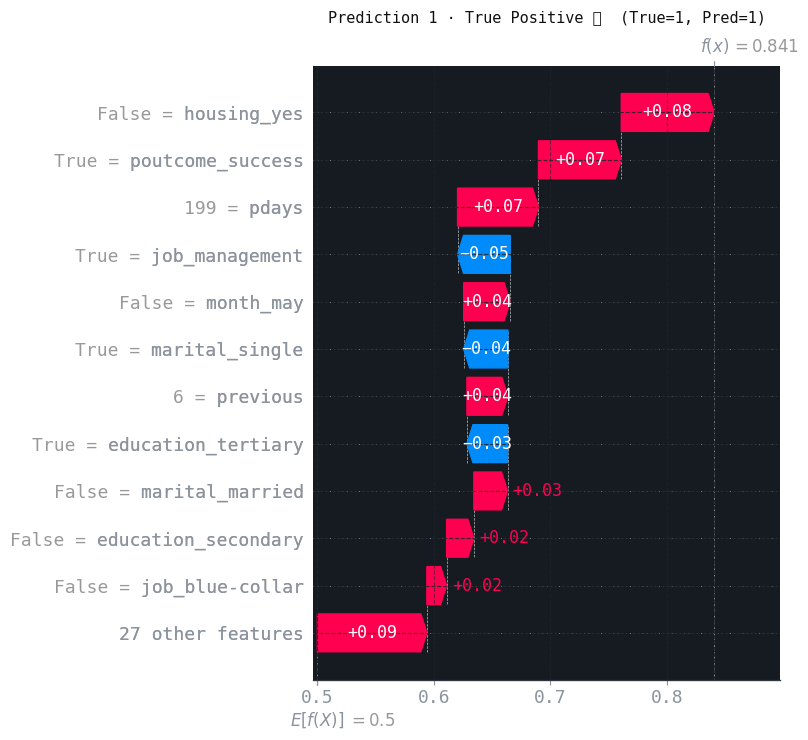

Saved → shap_waterfall_1.png


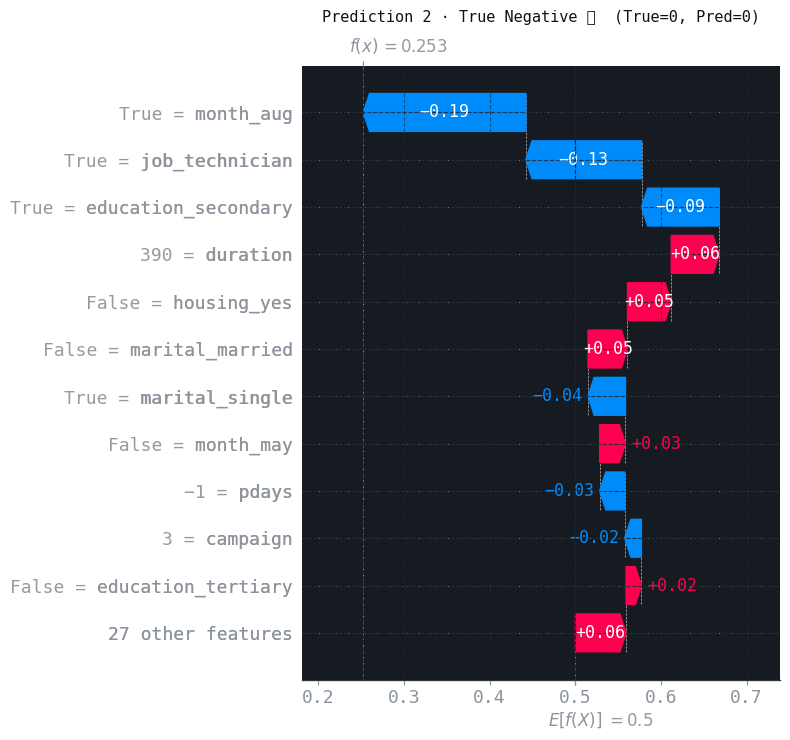

Saved → shap_waterfall_2.png


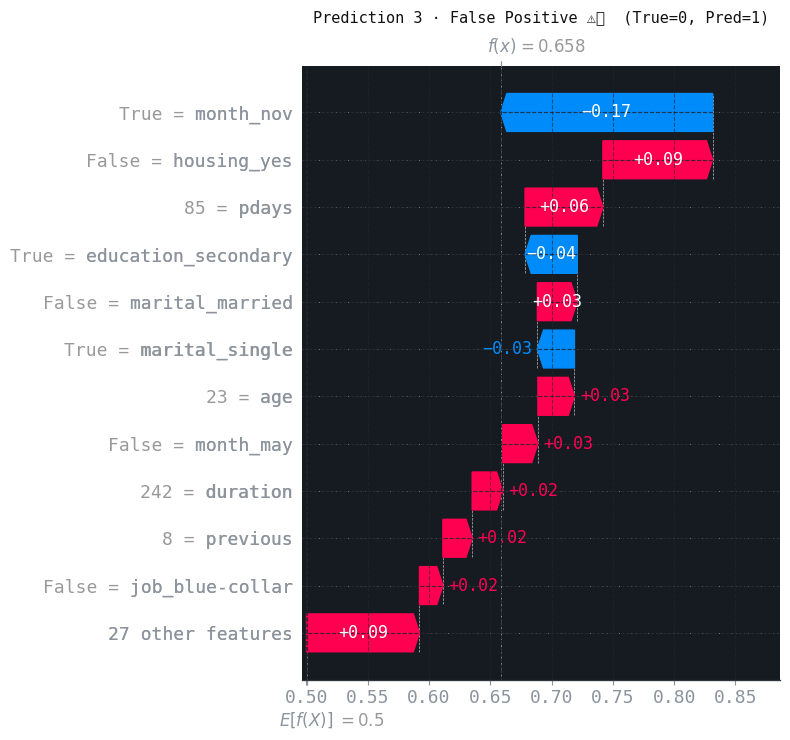

Saved → shap_waterfall_3.png


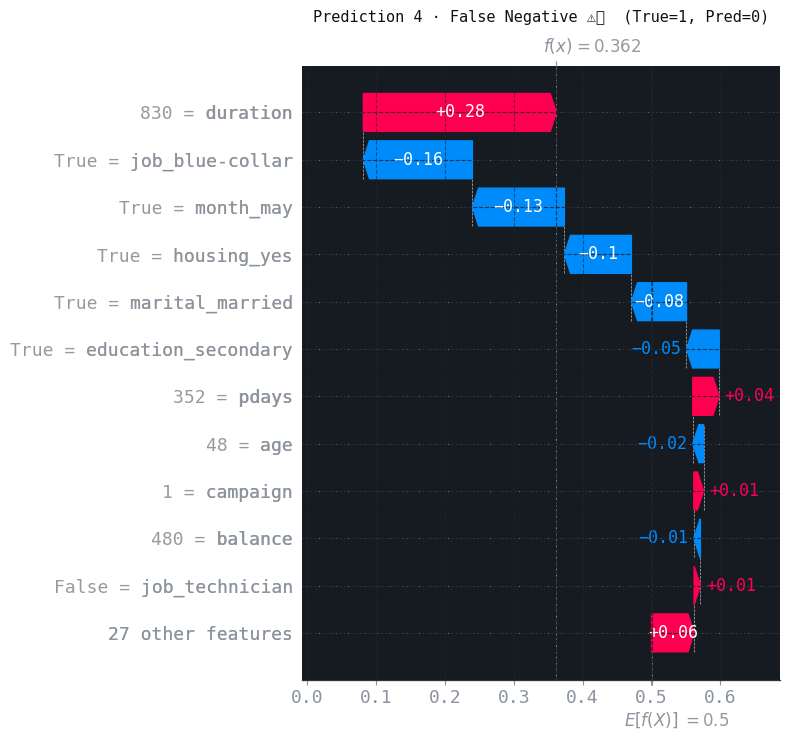

Saved → shap_waterfall_4.png


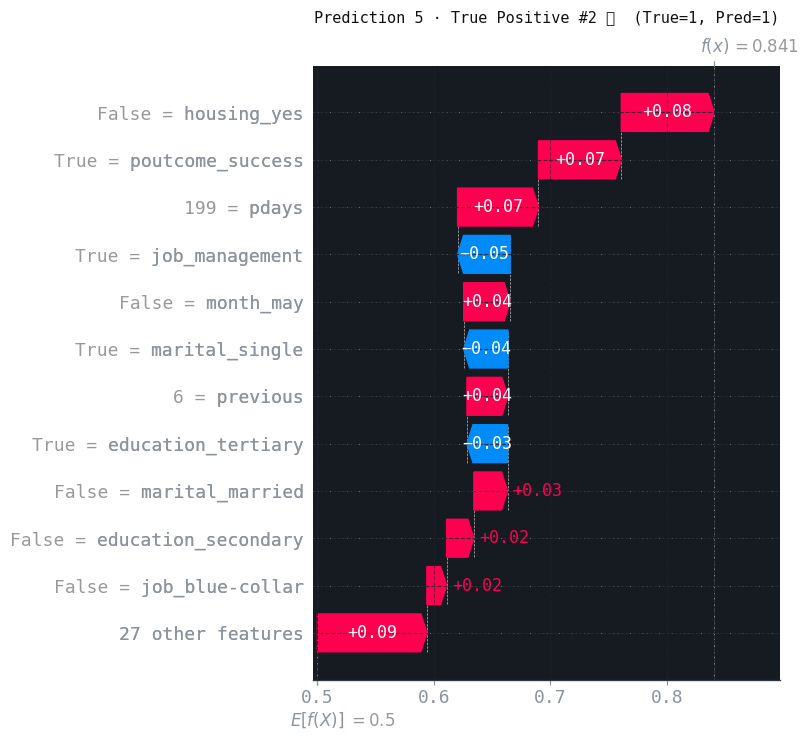

Saved → shap_waterfall_5.png


In [41]:
y_pred_shap = rf_model.predict(X_shap)
y_true_shap = y_test.iloc[sample_idx].values

tp = np.where((y_true_shap == 1) & (y_pred_shap == 1))[0]
tn = np.where((y_true_shap == 0) & (y_pred_shap == 0))[0]
fp = np.where((y_true_shap == 0) & (y_pred_shap == 1))[0]
fn = np.where((y_true_shap == 1) & (y_pred_shap == 0))[0]

pools  = [(tp, "True Positive ✅"), (tn, "True Negative ✅"),
          (fp, "False Positive ⚠️"), (fn, "False Negative ⚠️"), (tp, "True Positive #2 ✅")]
chosen = [(arr[0], lbl) for arr, lbl in pools if len(arr) > 0][:5]

shap_exp = shap.Explanation(
    values        = sv_yes,
    base_values   = explainer.expected_value[1],
    data          = X_shap.values,
    feature_names = X_shap.columns.tolist()
)

for i, (idx, label) in enumerate(chosen):
    plt.figure(figsize=(11, 5), facecolor="white")
    shap.waterfall_plot(shap_exp[idx], max_display=12, show=False)
    plt.title(f"Prediction {i+1} · {label}  "
              f"(True={y_true_shap[idx]}, Pred={y_pred_shap[idx]})",
              color="#111", fontsize=11, pad=10)
    plt.tight_layout()
    fname = f"shap_waterfall_{i+1}.png"
    plt.savefig(fname, dpi=130, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"Saved → {fname}")


### 7d · SHAP Dependence Plot — Top Feature
Shows how the **top SHAP feature** affects model output across all samples.


Top SHAP feature: duration


<Figure size 900x500 with 0 Axes>

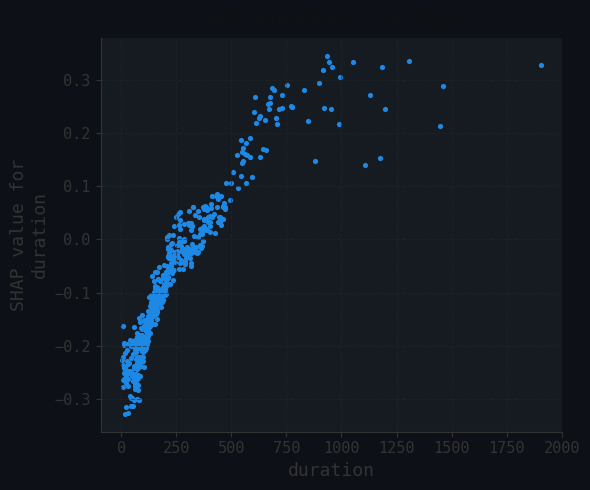

In [42]:
top_feat = pd.Series(np.abs(sv_yes).mean(axis=0),
                     index=X_shap.columns).idxmax()
print(f"Top SHAP feature: {top_feat}")

plt.figure(figsize=(9, 5), facecolor="white")
shap.dependence_plot(top_feat, sv_yes, X_shap,
                     interaction_index=None, show=False, dot_size=14)
plt.title(f"SHAP Dependence · {top_feat}", color="#111", fontsize=12, pad=10)
plt.tight_layout()
plt.savefig("shap_dependence.png", dpi=140, bbox_inches="tight", facecolor="white")
plt.show()



## 8 · Final Results Summary


                     F1-Score  ROC-AUC
Model                                 
Random Forest          0.5649   0.9060
Gradient Boosting      0.5564   0.9100
Logistic Regression    0.4686   0.8615


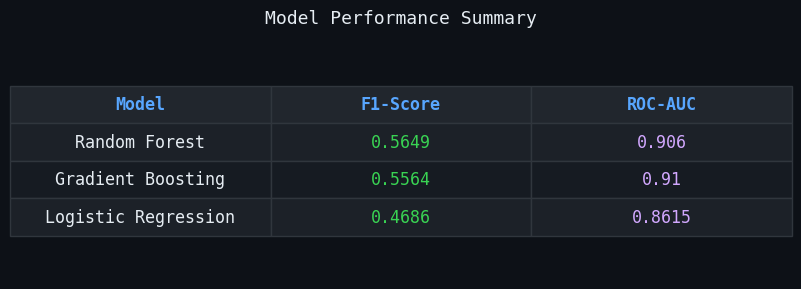


  Best model: Random Forest  (F1=0.5649  AUC=0.9060)


In [43]:
summary = pd.DataFrame({
    "Model":    list(results.keys()),
    "F1-Score": [round(v["f1"],  4) for v in results.values()],
    "ROC-AUC":  [round(v["auc"], 4) for v in results.values()],
}).set_index("Model").sort_values("F1-Score", ascending=False)

print(summary.to_string())

# ── Visual table ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 3))
fig.patch.set_facecolor(OBSIDIAN)
ax.set_facecolor(OBSIDIAN)
ax.axis("off")

data_rows = summary.reset_index().values.tolist()
col_labs  = ["Model", "F1-Score", "ROC-AUC"]
tbl = ax.table(cellText=data_rows, colLabels=col_labs,
               loc="center", cellLoc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(12)
tbl.scale(1.5, 2.2)

for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor(SURFACE2)
        cell.set_text_props(color=BLUE, fontweight="bold")
    else:
        bg = [SURFACE, "#1c2128"][r % 2]
        cell.set_facecolor(bg)
        val_txt = str(data_rows[r-1][c]) if c < len(data_rows[r-1]) else ""
        col_pick = GREEN if c == 1 else (VIOLET if c == 2 else TEXT)
        cell.set_text_props(color=col_pick)
    cell.set_edgecolor(BORDER)

ax.set_title("Model Performance Summary", color=TEXT, fontsize=13, pad=14)
plt.tight_layout()
plt.savefig("results_summary.png", dpi=140, bbox_inches="tight", facecolor=OBSIDIAN)
plt.show()

best = summary.index[0]
print(f"\n  Best model: {best}  "
      f"(F1={summary.loc[best,'F1-Score']:.4f}  AUC={summary.loc[best,'ROC-AUC']:.4f})")
